In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("synthetic_text_data.csv")
print(df.head())

                                                text          label
0  Artificial intelligence is advancing in health...     Technology
1  Football fans are excited about the upcoming W...         Sports
2  New policies regarding climate change have spa...       Politics
3  The latest blockbuster movie has shattered box...  Entertainment
4  Quantum computing promises to revolutionize in...     Technology


In [3]:
print(df.describe())

                                                     text       label
count                                                  85          85
unique                                                 85           4
top     Artificial intelligence is advancing in health...  Technology
freq                                                    1          30


In [4]:
print(df.shape)

(85, 2)


In [5]:
print(df.iloc[:, -1].value_counts())

label
Technology       30
Politics         21
Entertainment    19
Sports           15
Name: count, dtype: int64


In [6]:
X = df['text']
y = df['label']

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=47)

In [9]:
print("Training data: ", len(X_train))
print("Testing data: ", len(X_test))

Training data:  68
Testing data:  17


In [10]:
vectorizer = CountVectorizer()
X_train_c = vectorizer.fit_transform(X_train)
X_test_c = vectorizer.transform(X_test)

In [11]:
print("Training features:", X_train_c.shape)
print("Testing features:", X_test_c.shape)

Training features: (68, 392)
Testing features: (17, 392)


In [12]:
model = MultinomialNB()
model.fit(X_train_c, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](4,)","[15.,16.,13.,24.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](4,)","[-1.51,-1.45,-1.65,-1.04]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U13](4,)","['Entertainment','Politics','Sports','Technology']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](4, 392)","[[1.,0.,1.,...,1.,1.,1.], [4.,2.,0.,...,1.,0.,0.], [1.,0.,0.,...,2.,0.,0.], [0.,0.,0.,...,0.,1.,0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](4, 392)","[[-5.66,-6.35,-5.66,...,-5.66,-5.66,-5.66], [-4.76,-5.27,-6.37,...,-5.67,-6.37,-6.37], [-5.63,-6.32,-6.32,...,-5.22,-6.32,-6.32], [-6.51,-6.51,-6.51,...,-6.51,-5.81,-6.51]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,392


In [13]:
y_pred = model.predict(X_test_c)

In [14]:
acc = accuracy_score(y_test, y_pred)
print(acc)

0.8235294117647058


In [15]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[2 0 2 0]
 [0 5 0 0]
 [0 0 2 0]
 [1 0 0 5]]


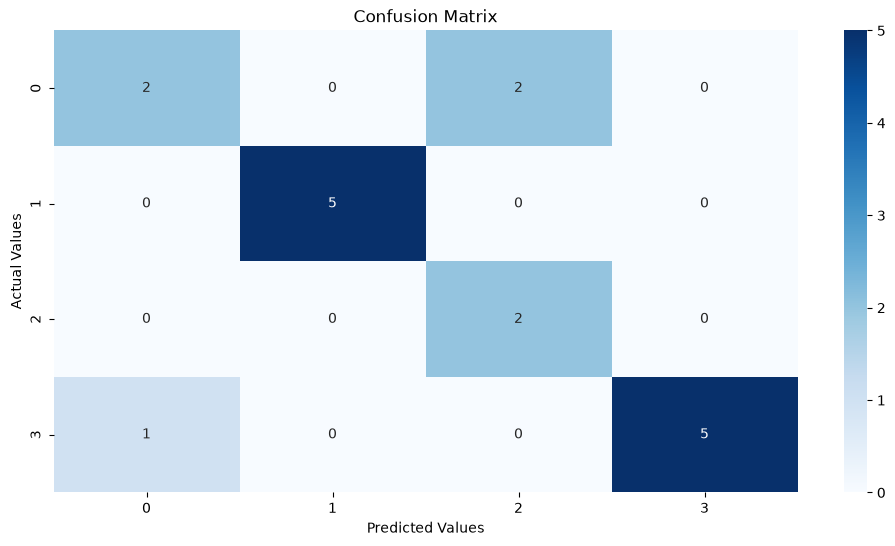

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12,6))
sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix")
plt.show()

Prediction on unseen text.

In [ ]:
new_text = [
    
]

In [18]:
new_text_c = vectorizer.transform(new_text)
pred = model.predict(new_text_c)

In [19]:
print("\nUnseen Text Predictions:")
for text, prediction in zip(new_text, pred):
    print("Text:", text)
    print("Prediction:", prediction)


Unseen Text Predictions:
Text: hello how was tommorow football match
Prediction: Sports
